In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from waymo_agent import *

In [3]:
from waymo_agent.osmnx.inspect import *
from waymo_agent.osmnx.osmnx_constants import *
from waymo_agent.osmnx.sparsify import *
from waymo_agent.osmnx.utils import _max_speed_int

In [4]:
G_raw = ox.graph_from_place(
    "Manhattan, New York, USA",
    network_type="drive",
    simplify=True,
)


print(f"Nodes: {G_raw.number_of_nodes()}")
print(f"Edges: {G_raw.number_of_edges()}")

Nodes: 4619
Edges: 9901


## Basic Save / Load

In [5]:
MAP_DIR

PosixPath('/Users/Akseldkw/coding/Columbia/RL-Project/maps')

In [6]:
ox.save_graphml(G_raw, filepath=MAP_DIR / MANHATTAN_RAW_GRAPH)

In [7]:
G_out = ox.load_graphml(filepath=MAP_DIR / MANHATTAN_RAW_GRAPH)

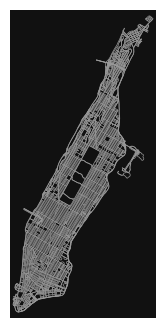

In [8]:
fig, ax = ox.plot_graph(G_out, node_size=0, edge_linewidth=0.5, figsize=(4, 4))

## Preprocess Graph

In [9]:
G = preprocess_graph(G_raw)

In [10]:
collect_unique_graph_attr(G, "maxspeed")

{2, 5, 10, 14, 15, 18, 20, 22, 25, 28, 30, 32, 35, 40, 44, 45, 48, 50}

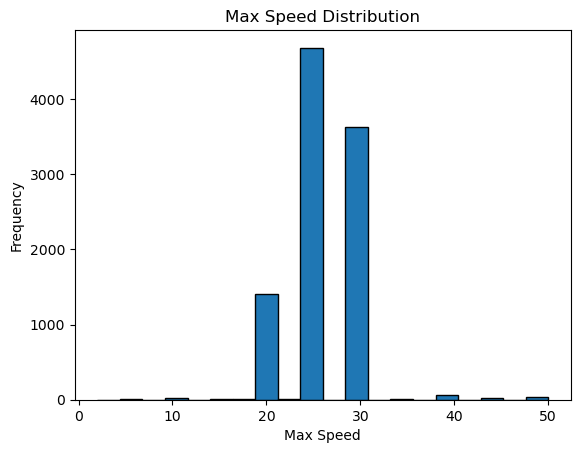

In [13]:
plot_maxspeed(G)

In [14]:
collect_unique_graph_attr(G, "maxspeed")

{2, 5, 10, 14, 15, 18, 20, 22, 25, 28, 30, 32, 35, 40, 44, 45, 48, 50}

In [15]:
ox.save_graphml(G, filepath=MAP_DIR / MANHATTAN_PROCESSED_GRAPH)

## Sparsify Graph

In [16]:
G = sparsify_graph(G)

Removing 4727 non-major edges...
Graph after edge removal: G_sparsified.number_of_nodes()=3517, G_sparsified.number_of_edges()=5173
Cleaning all edge attributes before simplification...
Cleaning all edge attributes before simplification...
Removing 110 isolated or pass-through nodes...
Cleaning all edge attributes before simplification...
Final simplified graph: G_ret.number_of_nodes()=772, G_ret.number_of_edges()=1609


In [17]:
sparse_graph_name = MANHATTAN_SPARSE_GRAPH.format(G.number_of_nodes())
sparse_graph_name

'manhattan-sparse-772-nodes.graphml'

In [18]:
ox.save_graphml(G, filepath=MAP_DIR / sparse_graph_name)

#### Load Sparse Graph

In [19]:
G = ox.load_graphml(filepath=MAP_DIR / sparse_graph_name)

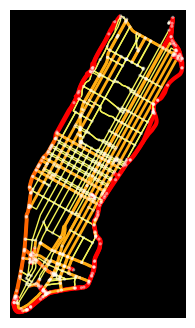

In [20]:
edge_colors, edge_widths = OSMNXConstants.get_edge_colors(G)
fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    **{**OX_PLOT_DEFAULTS | {"figsize": (4, 4)}},
)

## Enrich Graph 

Add lambda (demand) and charger info

In [21]:
G = ox.load_graphml(filepath=MAP_DIR / sparse_graph_name)
post_load(G)

In [32]:
enrich_graph(G)

Assigned 38 charging nodes.
Assigned lambda values to nodes. Total lambda: 8.7519 (target: 7.7200)


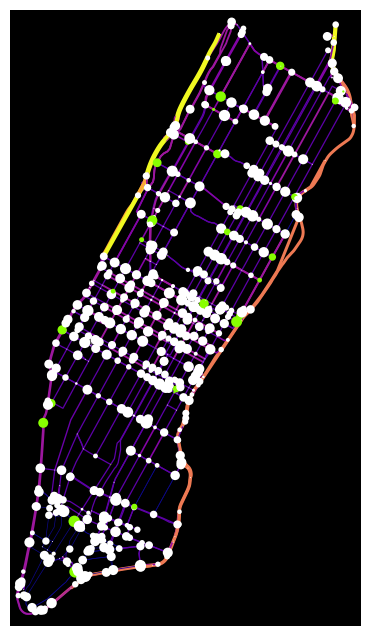

In [34]:
edge_colors, edge_widths = get_edge_color_by_speed(G)
node_colors, node_sizes = get_node_colors_and_sizes(G)
fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    node_size=node_sizes,
    node_color=node_colors,
    figsize=(8, 8),
    show=False,
    bgcolor="black",
)

In [35]:
name = MANHATTAN_ENRICHED_GRAPH.format(G.number_of_nodes())
ox.save_graphml(G, filepath=MAP_DIR / name)

In [36]:
name

'manhattan-sparse-772-nodes-enriched.graphml'